# Task 1: Data Preparation and Customer Analytics

In [142]:
import pandas as pd
# Read in QVI_transaction_data and OVI_purchase_behaviour

transaction_data_df =pd.read_csv('Task 1\QVI_transaction_data.csv')
purchase_behaviour_df = pd.read_csv('Task 1\QVI_purchase_behaviour.csv')

In [143]:
transaction_data_df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [144]:
purchase_behaviour_df

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


## Clean Transaction_Data_df

In [145]:
transaction_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


### Checking for duplicates

In [146]:
all_duplicates = transaction_data_df[transaction_data_df.duplicated(subset=['LYLTY_CARD_NBR','TXN_ID'], keep=False)].sort_values(by='LYLTY_CARD_NBR',ascending=True) #
print("All rows with duplicate IDs:")
display(all_duplicates)


All rows with duplicate IDs:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69847,43636,1,1446,517,9,Kettle Tortilla ChpsBtroot&Ricotta 150g,2,9.2
69846,43636,1,1446,517,99,Pringles Sthrn FriedChicken 134g,2,7.4
228855,43454,2,2034,628,95,Sunbites Whlegrn Crisps Frch/Onin 90g,1,1.7
228856,43454,2,2034,628,104,Infuzions Thai SweetChili PotatoMix 110g,1,3.8
135791,43338,3,3008,1142,15,Twisties Cheese 270g,2,9.2
...,...,...,...,...,...,...,...,...
5464,43326,271,271219,269517,3,Kettle Sensations Camembert & Fig 150g,1,4.6
135079,43376,272,272166,269865,99,Pringles Sthrn FriedChicken 134g,2,7.4
135080,43376,272,272166,269865,16,Smiths Crinkle Chips Salt & Vinegar 330g,2,11.4
203989,43583,272,272349,270140,32,Kettle Sea Salt And Vinegar 175g,2,10.8


In [147]:
all_duplicates = transaction_data_df[transaction_data_df.duplicated(subset=['PROD_NBR'], keep=False)].sort_values(by='PROD_NBR',ascending=True) #
print("All rows with duplicate IDs:")
display(all_duplicates)


All rows with duplicate IDs:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
85912,43451,71,71209,70317,1,Smiths Crinkle Cut Chips Barbecue 170g,2,5.8
247248,43438,118,118077,121128,1,Smiths Crinkle Cut Chips Barbecue 170g,2,5.8
227233,43424,232,232225,236494,1,Smiths Crinkle Cut Chips Barbecue 170g,2,5.8
85817,43390,70,70216,68728,1,Smiths Crinkle Cut Chips Barbecue 170g,2,5.8
219349,43336,57,57113,51909,1,Smiths Crinkle Cut Chips Barbecue 170g,2,5.8
...,...,...,...,...,...,...,...,...
120459,43609,40,40187,36964,114,Kettle Sensations Siracha Lime 150g,2,9.2
173074,43552,16,16347,14478,114,Kettle Sensations Siracha Lime 150g,1,4.6
71427,43496,45,45001,40426,114,Kettle Sensations Siracha Lime 150g,2,9.2
71443,43405,45,45012,40492,114,Kettle Sensations Siracha Lime 150g,2,9.2


In [148]:
transaction_data_df[transaction_data_df['PROD_NBR'] == 69]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
107,43329,152,152042,150473,69,Smiths Chip Thinly S/Cream&Onion 175g,3,9.0
327,43336,5,5136,5172,69,Smiths Chip Thinly S/Cream&Onion 175g,2,6.0
650,43350,32,32095,28588,69,Smiths Chip Thinly S/Cream&Onion 175g,2,6.0
1439,43568,77,77000,74912,69,Smiths Chip Thinly S/Cream&Onion 175g,1,3.0
...,...,...,...,...,...,...,...,...
263134,43420,197,197347,197315,69,Smiths Chip Thinly S/Cream&Onion 175g,2,6.0
263418,43467,213,213026,212000,69,Smiths Chip Thinly S/Cream&Onion 175g,2,6.0
263838,43342,230,230187,233203,69,Smiths Chip Thinly S/Cream&Onion 175g,2,6.0
264252,43306,247,247066,248980,69,Smiths Chip Thinly S/Cream&Onion 175g,2,6.0


In [149]:
transaction_data_df['LYLTY_CARD_NBR'].sort_values().unique()

array([   1000,    1002,    1003, ..., 2370751, 2370961, 2373711],
      shape=(72637,))

### Rename Columns Names to Camel Case and fix the column names

In [150]:
transaction_data_df=transaction_data_df.rename(columns={'DATE':'date','STORE_NBR':'store_id','LYLTY_CARD_NBR':'customer_id','TXN_ID':'transaction_id','PROD_NBR':'product_id','PROD_NAME':'product_name','PROD_QTY':'product_quantity','TOT_SALES':'total_sales'})

In [151]:
transaction_data_df

,date,store_id,customer_id,transaction_id,product_id,product_name,product_quantity,total_sales
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [152]:
purchase_behaviour_df

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [153]:
purchase_behaviour_df=purchase_behaviour_df.rename(columns={'LYLTY_CARD_NBR':'customer_id','LIFESTAGE':'lifestage','PREMIUM_CUSTOMER':'premium_customer'})

In [154]:
transaction_data_df

,date,store_id,customer_id,transaction_id,product_id,product_name,product_quantity,total_sales
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [155]:
purchase_behaviour_df

,customer_id,lifestage,premium_customer
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


### Fix up the columns

In [156]:
transaction_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              264836 non-null  int64  
 1   store_id          264836 non-null  int64  
 2   customer_id       264836 non-null  int64  
 3   transaction_id    264836 non-null  int64  
 4   product_id        264836 non-null  int64  
 5   product_name      264836 non-null  object 
 6   product_quantity  264836 non-null  int64  
 7   total_sales       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [157]:
transaction_data_df['date']

0         43390
1         43599
2         43605
3         43329
4         43330
          ...  
264831    43533
264832    43325
264833    43410
264834    43461
264835    43365
Name: date, Length: 264836, dtype: int64

#### Fix up 'date' from int to date

In [158]:
transaction_data_df['date'] = pd.to_datetime(transaction_data_df['date'], origin='1899-12-30', unit='D')

In [159]:
transaction_data_df

,date,store_id,customer_id,transaction_id,product_id,product_name,product_quantity,total_sales
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [160]:
transaction_data_df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,264836,NaN,NaN,NaN,2018-12-30 00:52:12.879215616,2018-07-01 00:00:00,2018-09-30 00:00:00,2018-12-30 00:00:00,2019-03-31 00:00:00,2019-06-30 00:00:00,NaN
store_id,264836.0,NaN,NaN,NaN,135.08011,1.0,70.0,130.0,203.0,272.0,76.78418
customer_id,264836.0,NaN,NaN,NaN,135549.476404,1000.0,70021.0,130357.5,203094.25,2373711.0,80579.978022
transaction_id,264836.0,NaN,NaN,NaN,135158.310815,1.0,67601.5,135137.5,202701.25,2415841.0,78133.026026
product_id,264836.0,NaN,NaN,NaN,56.583157,1.0,28.0,56.0,85.0,114.0,32.826638
product_name,264836,114,Kettle Mozzarella Basil & Pesto 175g,3304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_quantity,264836.0,NaN,NaN,NaN,1.907309,1.0,2.0,2.0,2.0,200.0,0.643654
total_sales,264836.0,NaN,NaN,NaN,7.3042,1.5,5.4,7.4,9.2,650.0,3.083226


In [161]:
transaction_data_df['product_id'].sort_values().unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114])

In [162]:
transaction_data_df['product_name'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

#### Fix up the spacing on the 'product_name' column

In [163]:
transaction_data_df['product_name'] = transaction_data_df['product_name'].str.strip()

In [164]:
transaction_data_df['product_name'].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

In [168]:
transaction_data_df['product_name'] = transaction_data_df['product_name'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [170]:
transaction_data_df['product_name'] = transaction_data_df['product_name'].str.replace(r'([a-zA-Z])(\d)', r'\1 \2', regex=True)

In [171]:
transaction_data_df['product_name'].unique()

array(['Natural Chip Compny SeaSalt 175g', 'CCs Nacho Cheese 175g',
       'Smiths Crinkle Cut Chips Chicken 170g',
       'Smiths Chip Thinly S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour Cream&Chives 210G',
       'Kettle Sensations Siracha Lime 150g', 'Twisties Cheese 270g',
       'WW Crinkle Cut Chicken 175g', 'Thins Chips Light& Tangy 175g',
       'CCs Original 175g', 'Burger Rings 220g',
       'NCC Sour Cream & Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt And Vinegar 175g',
       'Smiths Chip Thinly Cut Original 175g', 'Kettle Original 175g',
       'Red Rock Deli Thai Chilli&

In [172]:
replacements = {
    # common misspellings
    'Compny': 'Company',
    'Chps': 'Chips',
    'Chp': 'Chip',
    'Chnky': 'Chunky',
    'Chckn': 'Chicken',
    'Chikn': 'Chicken',
    'Crn': 'Corn',
    'Crnchers': 'Crunchers',
    'Infzns': 'Infuzions',
    'GrnWves': 'Grain Waves',
    'Btroot': 'Beetroot',
    'Gcamole': 'Guacamole',
    'Mzzrlla': 'Mozzarella',
    'Sthrn': 'Southern',
    'Spcy': 'Spicy',
    'Originl': 'Original',
    'Orgnl': 'Original',
    'saltd': 'Salted',
    'Vinegr': 'Vinegar',
    'Vingar': 'Vinegar',
    'Swt': 'Sweet',
    'Chli': 'Chilli',
    'Chlli': 'Chilli',
    'Hony': 'Honey',
    'Tmato': 'Tomato',
    'Hrb': 'Herb',
    'Spce': 'Spice',
    'Crm': 'Cream',
    'Ched': 'Cheddar',
    'Cheddr': 'Cheddar',
    'Mstrd': 'Mustard',
    'Chutny': 'Chutney',
    'Chimuchurri': 'Chimichurri',
    'Rst': 'Roast',
    'Pc': 'Piece'
}

for k, v in replacements.items():
    transaction_data_df['product_name'] = transaction_data_df['product_name'].str.replace(rf'\b{k}\b', v, regex=True)

In [177]:
transaction_data_df['product_name'].unique()

array(['Natural Chip Company SeaSalt 175g', 'CCs Nacho Cheese 175g',
       'Smiths Crinkle Cut Chips Chicken 170g',
       'Smiths Chip Thinly S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour Cream&Chives 210G',
       'Kettle Sensations Siracha Lime 150g', 'Twisties Cheese 270g',
       'WW Crinkle Cut Chicken 175g', 'Thins Chips Light& Tangy 175g',
       'CCs Original 175g', 'Burger Rings 220g',
       'NCC Sour Cream & Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle Original 330g',
       'Infuzions Corn Crunchers Tangy Guacamole 110g',
       'Kettle Sea Salt And Vinegar 175g',
       'Smiths Chip Thinly Cut Original 175g', 'Kettle Original 175g',
       'Red Rock Deli Thai

In [185]:
transaction_data_df[transaction_data_df['product_id'] == 4]

,date,store_id,customer_id,transaction_id,product_id,product_name,product_quantity,total_sales
41,2019-05-20,55,55073,48887,4,Dorito Corn Chip Supreme 380g,1,3.25
67,2018-08-16,83,83186,83162,4,Dorito Corn Chip Supreme 380g,2,6.50
157,2019-05-14,212,212203,211586,4,Dorito Corn Chip Supreme 380g,1,3.25
199,2018-08-18,269,269175,266095,4,Dorito Corn Chip Supreme 380g,2,6.50
236,2018-11-03,3,3164,1779,4,Dorito Corn Chip Supreme 380g,2,13.00
...,...,...,...,...,...,...,...,...
264457,2018-08-25,255,255218,254791,4,Dorito Corn Chip Supreme 380g,1,6.50
264470,2018-08-06,255,255470,255094,4,Dorito Corn Chip Supreme 380g,1,6.50
264536,2018-10-06,259,259056,257776,4,Dorito Corn Chip Supreme 380g,2,13.00
264584,2018-08-24,261,261292,260939,4,Dorito Corn Chip Supreme 380g,2,13.00


In [200]:
transaction_data_df.describe()


,date,store_id,customer_id,transaction_id,product_id,product_quantity,total_sales
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


<Axes: xlabel='total_sales'>

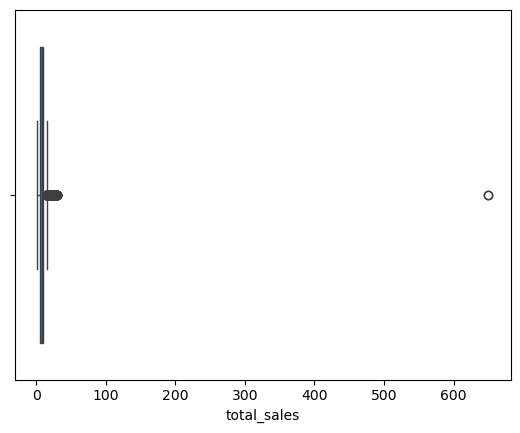

In [ ]:
import seaborn as sns
sns.boxplot(x='total_sales',data=transaction_data_df)

In [202]:
#transaction_data_df[transaction_data_df['total_sales'] > 100]
transaction_data_df[transaction_data_df['product_id'] == 4].sort_values(by='total_sales',ascending=False)

,date,store_id,customer_id,transaction_id,product_id,product_name,product_quantity,total_sales
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chip Supreme 380g,200,650.00
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chip Supreme 380g,200,650.00
108996,2019-02-28,133,133058,136340,4,Dorito Corn Chip Supreme 380g,3,19.50
99116,2019-05-20,39,39005,34628,4,Dorito Corn Chip Supreme 380g,5,16.25
55604,2019-05-18,212,212146,211291,4,Dorito Corn Chip Supreme 380g,5,16.25
...,...,...,...,...,...,...,...,...
16898,2018-08-18,3,3117,1568,4,Dorito Corn Chip Supreme 380g,1,3.25
16905,2018-08-18,10,10029,9202,4,Dorito Corn Chip Supreme 380g,1,3.25
17029,2018-08-14,106,106226,108087,4,Dorito Corn Chip Supreme 380g,1,3.25
17069,2018-08-18,147,147227,147098,4,Dorito Corn Chip Supreme 380g,1,3.25
